# HCP classification accuracy evaluation

Classification accuracy across cortical atlases and centroid-distance ranks.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.ticker import PercentFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

warnings.filterwarnings('ignore')
project_root = Path('../..').resolve()
import rise

font_path = project_root / 'font' / 'Whitney-Medium.otf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'
print(f'Font set: {font_name}')


Font set: Whitney


In [2]:
model_name = 'rise_hcp_pretrain_models'
model_root = project_root / 'models' / model_name
atlas_info_path = rise.fetch_multi_atlas_label_mapping()
train_atlas = ['DK', 'AAL', 'HarvardOxford', 'NM', 'Schaefer200', 'BN', 'Glasser', 'Schaefer400']
atlas_names = ['DK', 'AAL', 'HarvardOxford', 'NM', 'Schaefer200', 'Brainnetome', 'Glasser', 'Schaefer400']
distance_thresholds = [1, .9, .8, .7, .6, .5, .4, .3, .2, .1]
n_distance_bins = 10
n_jobs = 10
repeat_dirs = sorted(model_root.glob('repeat_*'), key=lambda path: int(re.search(r'\d+$', path.name).group()))
if not repeat_dirs: raise FileNotFoundError(model_root)
print(f'Model: {model_name}; repeats: {len(repeat_dirs)}')


Model: rise_hcp_pretrain_models; repeats: 10


In [3]:
atlas_info = pd.read_csv(atlas_info_path)

def compute_one_repeat(repeat_dir, train_atlas, atlas_info, num_bins=10):
    prediction_dir = repeat_dir / 'results'
    predictions = pd.concat([pd.read_csv(prediction_dir / f'test_group_pred_parcel_labels_{hemi}.csv') for hemi in ('lh', 'rh')], ignore_index=True)
    distances = ['Parcel label'] + [f'{atlas} Dis' for atlas in train_atlas]
    predictions = predictions.merge(atlas_info[distances], on='Parcel label', how='left', validate='one_to_one')
    result = []
    for atlas in train_atlas:
        distance = predictions[f'{atlas} Dis']
        _, bins = pd.qcut(distance, q=num_bins, retbins=True, duplicates='drop')
        result.append([(predictions.loc[distance <= threshold][f'gt_{atlas}'] == predictions.loc[distance <= threshold][f'pred_{atlas}']).mean() for threshold in bins[::-1][:-1]])
    return np.asarray(result)

accuracy_repeat_list = np.asarray(Parallel(n_jobs=n_jobs, backend='loky')(delayed(compute_one_repeat)(path, train_atlas, atlas_info, n_distance_bins) for path in repeat_dirs))
mean_atlas_accuracy = np.mean(accuracy_repeat_list, axis=0)
print(accuracy_repeat_list.shape)


(10, 8, 10)


In [4]:
def plot_atlas_barplot(data, atlas_names, thresh_values, title='Region classification across atlases stratified by centroid-distance ranks',
                       ylabel='Accuracy', xlabel='Cortical atlas', cmap='viridis', alpha=.4, bar_width=.2, group_gap=.45, reverse_atlas=True, figsize_scale=1.1):
    num_atlas, num_thresh = data.shape
    sort_idx = np.argsort(data[:, 5])[::-1]
    data = data[sort_idx]
    atlas_names = [atlas_names[i] for i in sort_idx]
    if reverse_atlas:
        data, atlas_names = data[::-1], atlas_names[::-1]
    colors = plt.cm.get_cmap(cmap)(np.linspace(0, 1, num_thresh))
    colors[:, 3] = alpha
    plt.figure(figsize=(figsize_scale * num_atlas, 3.8))
    y_min, y_max = np.min(data), np.max(data)
    text_offset = (y_max - y_min) * .02
    xtick_positions = []
    for a in range(num_atlas):
        group_base_x = a * (num_thresh * bar_width + group_gap)
        xtick_positions.append(group_base_x + (num_thresh - 1) * bar_width / 2)
        for i in range(num_thresh):
            x_pos, y_val = group_base_x + i * bar_width, data[a, i]
            plt.bar(
                x_pos,
                y_val,
                width=bar_width,
                color=colors[i],
                edgecolor='gray',
                linewidth=.5,
                zorder=2)
            plt.text(
                x_pos,
                y_val + text_offset,
                f'{y_val * 100:.1f}',
                ha='center',
                va='bottom',
                rotation=90,
                fontsize=6,
                color='black',
                zorder=3,
                alpha=.8)
    plt.xticks(xtick_positions, atlas_names, fontsize=10)
    plt.yticks(fontsize=9)
    plt.xlabel(xlabel, fontsize=14, labelpad=8)
    plt.ylabel(ylabel, fontsize=14, labelpad=4)
    plt.title(title, fontsize=16, pad=16)
    plt.ylim(y_min * .98, y_max * 1.05)
    last_x_pos = (num_atlas - 1) * (num_thresh * bar_width +
                                    group_gap) + (num_thresh - 1) * bar_width
    plt.xlim(-bar_width * 4, last_x_pos + bar_width * 4)
    plt.grid(
        axis='y',
        color='lightgray',
        linestyle='--',
        linewidth=.5,
        alpha=.7,
        zorder=1)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    for spine in ax.spines.values():
        spine.set_color('gray')
        spine.set_linewidth(.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    custom_cmap = mcolors.ListedColormap(colors)
    bounds = np.arange(num_thresh + 1)
    norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    cax = inset_axes(ax, width='20%', height='2.5%', loc='upper left', borderpad=2.5)
    cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.ax.set_title('Centroid-distance rank (%)', fontsize=10, pad=6)
    cbar.set_ticks(bounds[:-1] + .5)
    cbar.set_ticklabels([f'{int(t * 100)}' for t in thresh_values])
    cbar.ax.tick_params(labelsize=7, length=0)
    cbar.outline.set_edgecolor('gray')
    cbar.outline.set_linewidth(.5)
    plt.tight_layout()
    plt.show()


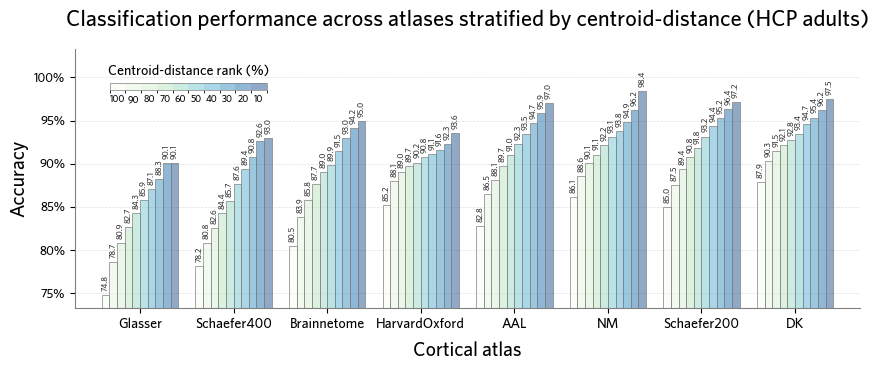

In [5]:
plot_atlas_barplot(mean_atlas_accuracy, atlas_names, distance_thresholds, cmap='GnBu', alpha=.45, title='Classification performance across atlases stratified by centroid-distance (HCP adults)')
